Para abrir o notebook no Google Colab, altere o domínio `github.com` para `githubtocolab.com`

<div class="alert alert-block alert-danger">
Para praticar programação, é importante que você erre, leia as mensagens de erro e tente corrigí-los.
    
Dessa forma, no Google Colab, é importante que você DESATIVE OS RECURSOS DE AUTOCOMPLETAR:

- Menu Ferramentas -> Configurações
- Na janela que é aberta:
  - Seção Editor -> Desativar "Mostrar sugestões de preenchimento de código com base no contexto"
  - Seção Assistência de IA -> Desabilitar itens

Na versão em inglês:

- Menu Tools -> Settings
- Na janela que é aberta:
  - Seção Editor -> Desativar "Show context-powered code completions"
  - Seção AI Assistance -> Desabilitar itens
</div>

# PSI3471 - Aula de Exercícios 03

# Perceptron de Rosenblatt e Regressão Logística

# Exercício 1

Neste exercício vamos utilizar o neurônio de Rosenblatt para implementar a função lógica AND.

Iniciamos importando as bibliotecas necessárias para implementar o neurônio de Rosenblatt.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Vamos gerar os dados de treinamento do problema começando pelo AND.

<div class="alert alert-block alert-success">
Complete o código a seguir:
</div>

In [ ]:
Nt = 100  # número de pontos de treinamento

#############
# x deve ser uma matriz com Nt linhas e 2 colunas com valores 0 ou 1 aleatórios,
# que pode ser gerada usando as funções np.round e np.random.uniform.
# d deve ser um vetor coluna com Nt linhas contendo o resultado da função lógica
# AND aplicada ao vetor x. Para isso use a função np.logical_and.
# Note que a função np.logical_and devolve um vetor com elementos do tipo boolean.
# Para transformar os elementos para o tipo inteiro, basta multiplicá-lo por 1
# ou usar o método .astype(int)

x = np.round(np.random.uniform(0, 1, (Nt, 2)))

d = 1*(np.logical_and(x[:,0],x[:,1]))
d=d.reshape(Nt,1)
print(d.shape)
#############

(100, 1)


A função a seguir implementa o neurônio de Rosenblatt no modo mini-batch. Modifique o programa do algoritmo LMS no modo mini- inserindo a função de ativação.
Para obter 0 ou 1 na saída, deve-se usar a função degrau em vez da função sinal. Para isso, use a função `np.heaviside`.
Uma outra modificação que deve ser considerada é a inicialização dos pesos e bias, que agora devem ser inicializados com valores aleatórios uniformemente distribuídos no intervalo [-dw, dw].

<div class="alert alert-block alert-success">
Complete o código a seguir:
</div>

In [ ]:
def Rosenblatt_minibatch(x, d, eta, Nt, Ne, Nb, dw):
    """
    W = Rosenblatt_minibatch(x, d, eta, Nt, Ne, Nb)
    x: sinal de entrada
    d: sinal desejado
    eta: passo de adaptação
    Nt: número de dados de treinamento
    Ne: número de épocas
    Nb: tamanho do mini-batch
    dw: inicialização dos pesos e bias com distribuição uniforme no invervalo [-dw, dw]
    """
    """
    Novamente, vamos juntar o sinal de entrada e o sinal desejado em um único vetor,
    uma vez que a cada época vamos embaralhar os dados.
    Ao fazer isso, já inserimos uma coluna de 1's para levar em conta o bias.
    """
    M=x.shape[1]
    Nmb=int(np.floor(Nt / Nb))
    eta=eta/Nb
    W=np.random.uniform(-dw, dw, [Ne*Nmb+1,M+1])
    Xd=np.hstack((np.ones((Nt,1)),x,d))
    for k in range(Ne):
        np.random.shuffle(Xd)
        x = Xd[:, 0 : M + 1]
        d = Xd[:, [M + 1]]
        for l in range(Nmb):
          dmb = d[Nb*l:Nb*(l+1)]
          dmb = dmb.ravel()
          xmb = x[Nb*l:Nb*(l+1),:]
          m=l+k*Nmb
          u=xmb@W[m]
          y=np.heaviside(u,0)
          emb=dmb-y
          W[m+1,:]=W[m]+eta*xmb.T@emb
    #############

    return W
    #############



In [ ]:
eta = 0.5  # passo de adaptação do algoritmo de Rosenblatt
Nb = 20
Ne = 100
dw = 2

#############  Complete o código a seguir
W = Rosenblatt_minibatch(x, d, eta, Nt, Ne, Nb, dw)

# Wfinal deve ser os valores de pesos e bias da última iteração
Wfinal = W[-1,:]
print(Wfinal)
#############

[-1.49764173  1.28275761  0.24448594]


<div class="alert alert-block alert-success">
Complete o código a seguir:
</div>

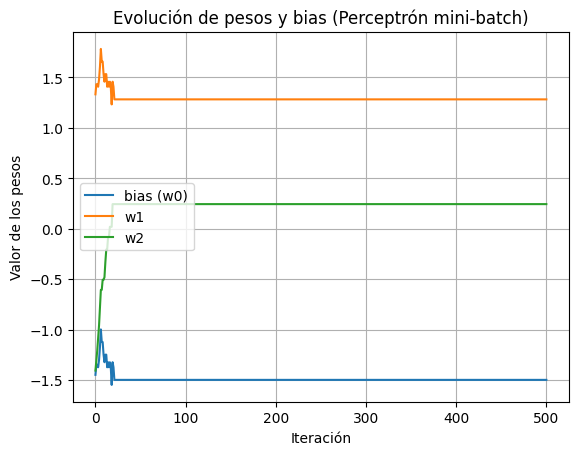

In [ ]:
# Gere um gráfico para mostrar os pesos e bias ao longo das iterações
import matplotlib.pyplot as plt

plt.figure()

# Iteraciones
iters = range(W.shape[0])

# Graficar bias y pesos
plt.plot(iters, W[:, 0], label="bias (w0)")
plt.plot(iters, W[:, 1], label="w1")
plt.plot(iters, W[:, 2], label="w2")

plt.xlabel("Iteración")
plt.ylabel("Valor de los pesos")
plt.title("Evolución de pesos y bias (Perceptrón mini-batch)")
plt.grid(True)
plt.legend()

plt.show()

<div class="alert alert-block alert-success">
Complete o código a seguir:
</div>

Taxa de erro: 0.0


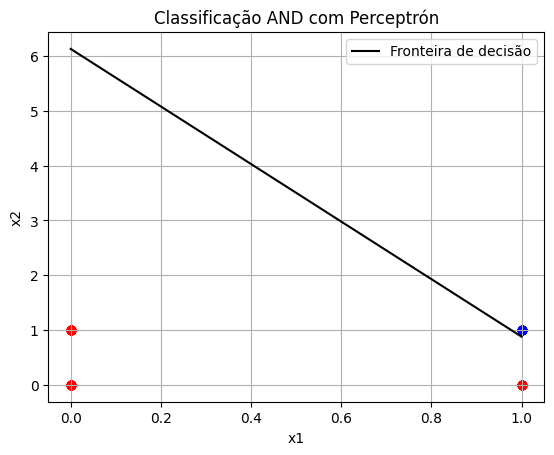

In [ ]:
# Gere os dados de teste, calcule a taxa de erro e gere a reta de separação das
# regiões, mostrando em um mesmo gráfico a reta e os dados de teste classificados.
# Comente o resultado, explicando se é possível utilizar o neurônio de Rosenblatt
# para implementar esta função lógica.
import numpy as np
import matplotlib.pyplot as plt

#Generar datos de test
Nt_test = 100
x_test = np.round(np.random.uniform(0, 1, (Nt_test, 2)))

d_test = np.logical_and(x_test[:, 0], x_test[:, 1]).astype(int)

#Agregar bias
x_test_b = np.hstack((np.ones((Nt_test, 1)), x_test))

#Usar pesos finales
Wfinal = W[-1, :]

# Predicción
u = x_test_b @ Wfinal
y_pred = np.heaviside(u, 0)

#Error
error = np.mean(y_pred != d_test)
print("Taxa de erro:", error)

# Gráfico
plt.figure()

# Separar clases
for i in range(Nt_test):
    if y_pred[i] == 0:
        plt.scatter(x_test[i, 0], x_test[i, 1], color='red')
    else:
        plt.scatter(x_test[i, 0], x_test[i, 1], color='blue')

# Reta de separação
# Wfinal = [w0, w1, w2]
w0, w1, w2 = Wfinal

x_vals = np.linspace(0, 1, 100)

# Evitar división por cero
if w2 != 0:
    y_vals = -(w0 + w1 * x_vals) / w2
    plt.plot(x_vals, y_vals, 'k-', label="Fronteira de decisão")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Classificação AND com Perceptrón")
plt.legend()
plt.grid(True)

plt.show()




# Exercício 2

Repita o exercício anterior considerando as portas lógicas OR e o XOR.

## Resolução

(100, 1)
[-0.09972929  1.54280963  0.11513344]


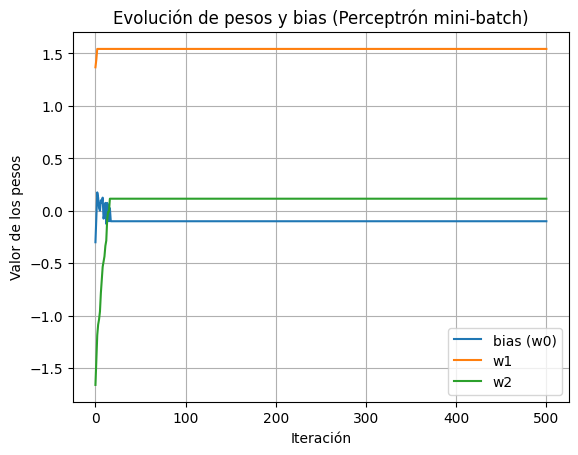

Taxa de erro: 0.0


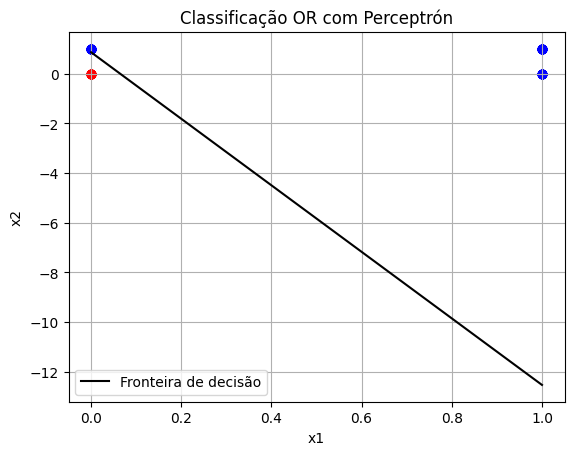

In [ ]:
Nt = 100  # número de pontos de treinamento
x = np.round(np.random.uniform(0, 1, (Nt, 2)))

d = 1*(np.logical_or(x[:,0],x[:,1]))
d=d.reshape(Nt,1)
print(d.shape)

eta = 0.5  # passo de adaptação do algoritmo de Rosenblatt
Nb = 20
Ne = 100
dw = 2

#############  Complete o código a seguir
W = Rosenblatt_minibatch(x, d, eta, Nt, Ne, Nb, dw)

# Wfinal deve ser os valores de pesos e bias da última iteração
Wfinal = W[-1,:]
print(Wfinal)
#############

# Gere um gráfico para mostrar os pesos e bias ao longo das iterações
import matplotlib.pyplot as plt

plt.figure()

# Iteraciones
iters = range(W.shape[0])

# Graficar bias y pesos
plt.plot(iters, W[:, 0], label="bias (w0)")
plt.plot(iters, W[:, 1], label="w1")
plt.plot(iters, W[:, 2], label="w2")

plt.xlabel("Iteración")
plt.ylabel("Valor de los pesos")
plt.title("Evolución de pesos y bias (Perceptrón mini-batch)")
plt.grid(True)
plt.legend()

plt.show()

import numpy as np
import matplotlib.pyplot as plt

#Generar datos de test
Nt_test = 100
x_test = np.round(np.random.uniform(0, 1, (Nt_test, 2)))

d_test = np.logical_or(x_test[:, 0], x_test[:, 1]).astype(int)

#Agregar bias
x_test_b = np.hstack((np.ones((Nt_test, 1)), x_test))

#Usar pesos finales
Wfinal = W[-1, :]

# Predicción
u = x_test_b @ Wfinal
y_pred = np.heaviside(u, 0)

#Error
error = np.mean(y_pred != d_test)
print("Taxa de erro:", error)

# Gráfico
plt.figure()

# Separar clases
for i in range(Nt_test):
    if y_pred[i] == 0:
        plt.scatter(x_test[i, 0], x_test[i, 1], color='red')
    else:
        plt.scatter(x_test[i, 0], x_test[i, 1], color='blue')

# Reta de separação
# Wfinal = [w0, w1, w2]
w0, w1, w2 = Wfinal

x_vals = np.linspace(0, 1, 100)

# Evitar división por cero
if w2 != 0:
    y_vals = -(w0 + w1 * x_vals) / w2
    plt.plot(x_vals, y_vals, 'k-', label="Fronteira de decisão")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Classificação OR com Perceptrón")
plt.legend()
plt.grid(True)

plt.show()

(100, 1)
[0.06847258 0.04054261 0.03607924]


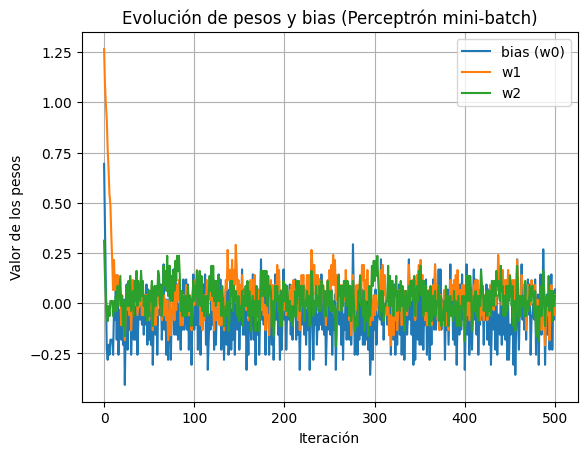

Taxa de erro: 0.45


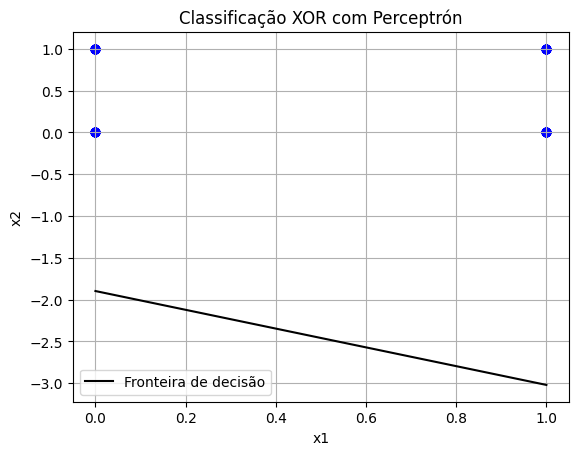

In [ ]:
Nt = 100  # número de pontos de treinamento
x = np.round(np.random.uniform(0, 1, (Nt, 2)))

d = 1*(np.logical_xor(x[:,0],x[:,1]))
d=d.reshape(Nt,1)
print(d.shape)

eta = 0.5  # passo de adaptação do algoritmo de Rosenblatt
Nb = 20
Ne = 100
dw = 2

#############  Complete o código a seguir
W = Rosenblatt_minibatch(x, d, eta, Nt, Ne, Nb, dw)

# Wfinal deve ser os valores de pesos e bias da última iteração
Wfinal = W[-1,:]
print(Wfinal)
#############

# Gere um gráfico para mostrar os pesos e bias ao longo das iterações
import matplotlib.pyplot as plt

plt.figure()

# Iteraciones
iters = range(W.shape[0])

# Graficar bias y pesos
plt.plot(iters, W[:, 0], label="bias (w0)")
plt.plot(iters, W[:, 1], label="w1")
plt.plot(iters, W[:, 2], label="w2")

plt.xlabel("Iteración")
plt.ylabel("Valor de los pesos")
plt.title("Evolución de pesos y bias (Perceptrón mini-batch)")
plt.grid(True)
plt.legend()

plt.show()

import numpy as np
import matplotlib.pyplot as plt

#Generar datos de test
Nt_test = 100
x_test = np.round(np.random.uniform(0, 1, (Nt_test, 2)))

d_test = np.logical_xor(x_test[:, 0], x_test[:, 1]).astype(int)

#Agregar bias
x_test_b = np.hstack((np.ones((Nt_test, 1)), x_test))

#Usar pesos finales
Wfinal = W[-1, :]

# Predicción
u = x_test_b @ Wfinal
y_pred = np.heaviside(u, 0)

#Error
error = np.mean(y_pred != d_test)
print("Taxa de erro:", error)

# Gráfico
plt.figure()

# Separar clases
for i in range(Nt_test):
    if y_pred[i] == 0:
        plt.scatter(x_test[i, 0], x_test[i, 1], color='red')
    else:
        plt.scatter(x_test[i, 0], x_test[i, 1], color='blue')

# Reta de separação
# Wfinal = [w0, w1, w2]
w0, w1, w2 = Wfinal

x_vals = np.linspace(0, 1, 100)

# Evitar división por cero
if w2 != 0:
    y_vals = -(w0 + w1 * x_vals) / w2
    plt.plot(x_vals, y_vals, 'k-', label="Fronteira de decisão")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Classificação XOR com Perceptrón")
plt.legend()
plt.grid(True)

plt.show()

# Exercício 3

Repita o exercício para as portas lógicas AND, OR e XOR considerando a otimização do modelo utilizando a regressão logística com as seguintes funções custo:
- Erro quadrático médio
- Entropia cruzada

## Resolução

In [8]:
def Rosenblatt_minibatch_MSE(x, d, eta, Nt, Ne, Nb, dw):
    """
    W = Rosenblatt_minibatch(x, d, eta, Nt, Ne, Nb)
    x: sinal de entrada
    d: sinal desejado
    eta: passo de adaptação
    Nt: número de dados de treinamento
    Ne: número de épocas
    Nb: tamanho do mini-batch
    dw: inicialização dos pesos e bias com distribuição uniforme no invervalo [-dw, dw]
    """
    """
    Novamente, vamos juntar o sinal de entrada e o sinal desejado em um único vetor,
    uma vez que a cada época vamos embaralhar os dados.
    Ao fazer isso, já inserimos uma coluna de 1's para levar em conta o bias.
    """
    M=x.shape[1]
    Nmb=int(np.floor(Nt / Nb))
    eta=eta/Nb
    W=np.random.uniform(-dw, dw, [Ne*Nmb+1,M+1])
    Xd=np.hstack((np.ones((Nt,1)),x,d))
    for k in range(Ne):
        np.random.shuffle(Xd)
        x = Xd[:, 0 : M + 1]
        d = Xd[:, [M + 1]]
        for l in range(Nmb):
          dmb = d[Nb*l:Nb*(l+1)]
          dmb = dmb.ravel()
          xmb = x[Nb*l:Nb*(l+1),:]
          m=l+k*Nmb
          u=xmb@W[m]
          y = 1 / (1 + np.exp(-np.clip(u, -50, 50)))
          emb=dmb-y
          gradiente=emb*y*(1-y)
          W[m+1,:]=W[m]+eta*xmb.T@gradiente
    #############

    return W

(100, 1)
[-2.84674121  1.79606176  1.86116826]


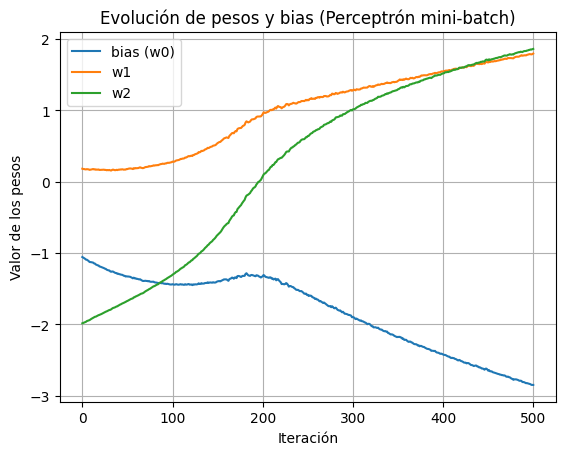

Taxa de erro: 0.0


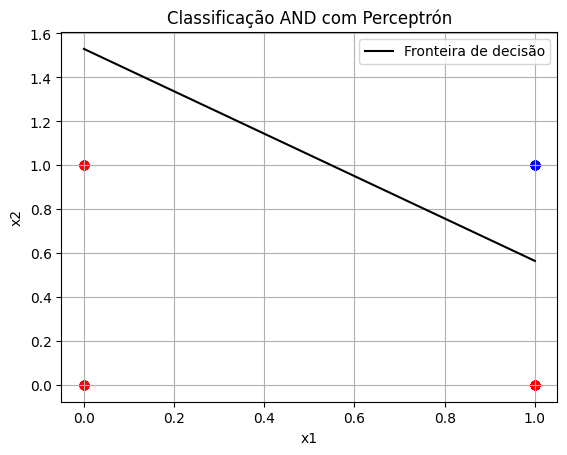

In [9]:
Nt = 100  # número de pontos de treinamento
x = np.round(np.random.uniform(0, 1, (Nt, 2)))

d = 1*(np.logical_and(x[:,0],x[:,1]))
d=d.reshape(Nt,1)
print(d.shape)

eta = 0.5  # passo de adaptação do algoritmo de Rosenblatt
Nb = 20
Ne = 100
dw = 2

#############  Complete o código a seguir
W = Rosenblatt_minibatch_MSE(x, d, eta, Nt, Ne, Nb, dw)

# Wfinal deve ser os valores de pesos e bias da última iteração
Wfinal = W[-1,:]
print(Wfinal)
#############

# Gere um gráfico para mostrar os pesos e bias ao longo das iterações
import matplotlib.pyplot as plt

plt.figure()

# Iteraciones
iters = range(W.shape[0])

# Graficar bias y pesos
plt.plot(iters, W[:, 0], label="bias (w0)")
plt.plot(iters, W[:, 1], label="w1")
plt.plot(iters, W[:, 2], label="w2")

plt.xlabel("Iteración")
plt.ylabel("Valor de los pesos")
plt.title("Evolución de pesos y bias (Perceptrón mini-batch)")
plt.grid(True)
plt.legend()

plt.show()

import numpy as np
import matplotlib.pyplot as plt

#Generar datos de test
Nt_test = 100
x_test = np.round(np.random.uniform(0, 1, (Nt_test, 2)))

d_test = np.logical_and(x_test[:, 0], x_test[:, 1]).astype(int)

#Agregar bias
x_test_b = np.hstack((np.ones((Nt_test, 1)), x_test))

#Usar pesos finales
Wfinal = W[-1, :]

# Predicción
u = x_test_b @ Wfinal
y_pred = np.heaviside(u, 0)

#Error
error = np.mean(y_pred != d_test)
print("Taxa de erro:", error)

# Gráfico
plt.figure()

# Separar clases
for i in range(Nt_test):
    if y_pred[i] == 0:
        plt.scatter(x_test[i, 0], x_test[i, 1], color='red')
    else:
        plt.scatter(x_test[i, 0], x_test[i, 1], color='blue')

# Reta de separação
# Wfinal = [w0, w1, w2]
w0, w1, w2 = Wfinal

x_vals = np.linspace(0, 1, 100)

# Evitar división por cero
if w2 != 0:
    y_vals = -(w0 + w1 * x_vals) / w2
    plt.plot(x_vals, y_vals, 'k-', label="Fronteira de decisão")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Classificação AND com Perceptrón")
plt.legend()
plt.grid(True)

plt.show()

(100, 1)
[-1.04223062  2.68636525  2.60840968]


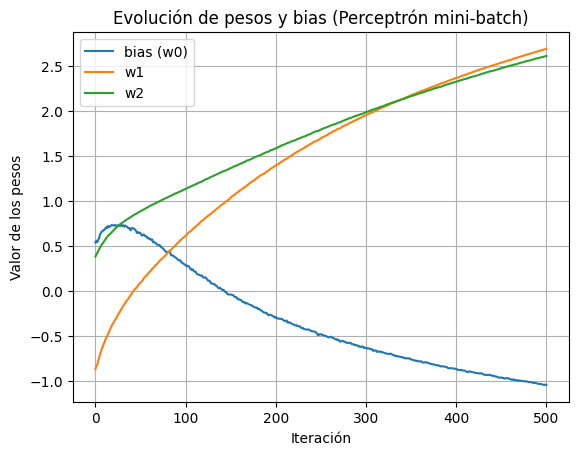

Taxa de erro: 0.0


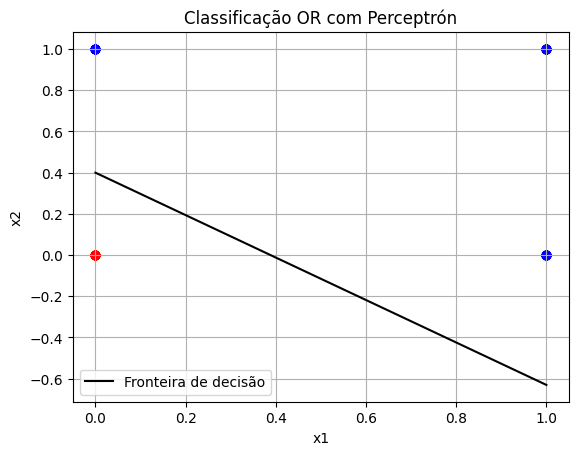

In [10]:
Nt = 100  # número de pontos de treinamento
x = np.round(np.random.uniform(0, 1, (Nt, 2)))

d = 1*(np.logical_or(x[:,0],x[:,1]))
d=d.reshape(Nt,1)
print(d.shape)

eta = 0.5  # passo de adaptação do algoritmo de Rosenblatt
Nb = 20
Ne = 100
dw = 2

#############  Complete o código a seguir
W = Rosenblatt_minibatch_MSE(x, d, eta, Nt, Ne, Nb, dw)

# Wfinal deve ser os valores de pesos e bias da última iteração
Wfinal = W[-1,:]
print(Wfinal)
#############

# Gere um gráfico para mostrar os pesos e bias ao longo das iterações
import matplotlib.pyplot as plt

plt.figure()

# Iteraciones
iters = range(W.shape[0])

# Graficar bias y pesos
plt.plot(iters, W[:, 0], label="bias (w0)")
plt.plot(iters, W[:, 1], label="w1")
plt.plot(iters, W[:, 2], label="w2")

plt.xlabel("Iteración")
plt.ylabel("Valor de los pesos")
plt.title("Evolución de pesos y bias (Perceptrón mini-batch)")
plt.grid(True)
plt.legend()

plt.show()

import numpy as np
import matplotlib.pyplot as plt

#Generar datos de test
Nt_test = 100
x_test = np.round(np.random.uniform(0, 1, (Nt_test, 2)))

d_test = np.logical_or(x_test[:, 0], x_test[:, 1]).astype(int)

#Agregar bias
x_test_b = np.hstack((np.ones((Nt_test, 1)), x_test))

#Usar pesos finales
Wfinal = W[-1, :]

# Predicción
u = x_test_b @ Wfinal
y_pred = np.heaviside(u, 0)

#Error
error = np.mean(y_pred != d_test)
print("Taxa de erro:", error)

# Gráfico
plt.figure()

# Separar clases
for i in range(Nt_test):
    if y_pred[i] == 0:
        plt.scatter(x_test[i, 0], x_test[i, 1], color='red')
    else:
        plt.scatter(x_test[i, 0], x_test[i, 1], color='blue')

# Reta de separação
# Wfinal = [w0, w1, w2]
w0, w1, w2 = Wfinal

x_vals = np.linspace(0, 1, 100)

# Evitar división por cero
if w2 != 0:
    y_vals = -(w0 + w1 * x_vals) / w2
    plt.plot(x_vals, y_vals, 'k-', label="Fronteira de decisão")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Classificação OR com Perceptrón")
plt.legend()
plt.grid(True)

plt.show()

(100, 1)
[-0.33484856 -0.1775327   0.68804051]


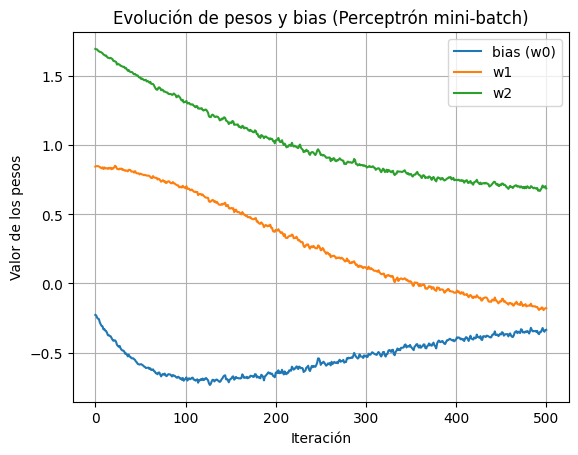

Taxa de erro: 0.51


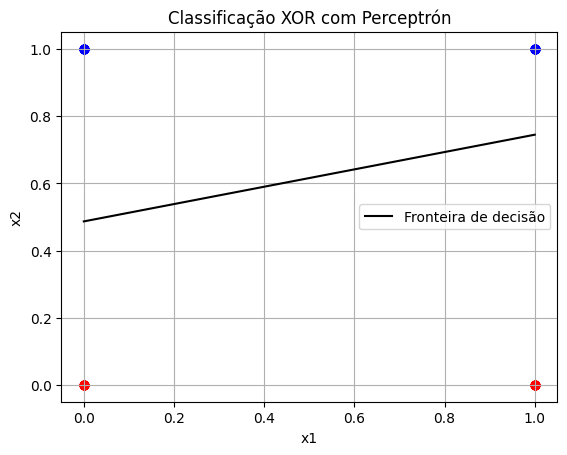

In [11]:
Nt = 100  # número de pontos de treinamento
x = np.round(np.random.uniform(0, 1, (Nt, 2)))

d = 1*(np.logical_xor(x[:,0],x[:,1]))
d=d.reshape(Nt,1)
print(d.shape)

eta = 0.5  # passo de adaptação do algoritmo de Rosenblatt
Nb = 20
Ne = 100
dw = 2

#############  Complete o código a seguir
W = Rosenblatt_minibatch_MSE(x, d, eta, Nt, Ne, Nb, dw)

# Wfinal deve ser os valores de pesos e bias da última iteração
Wfinal = W[-1,:]
print(Wfinal)
#############

# Gere um gráfico para mostrar os pesos e bias ao longo das iterações
import matplotlib.pyplot as plt

plt.figure()

# Iteraciones
iters = range(W.shape[0])

# Graficar bias y pesos
plt.plot(iters, W[:, 0], label="bias (w0)")
plt.plot(iters, W[:, 1], label="w1")
plt.plot(iters, W[:, 2], label="w2")

plt.xlabel("Iteración")
plt.ylabel("Valor de los pesos")
plt.title("Evolución de pesos y bias (Perceptrón mini-batch)")
plt.grid(True)
plt.legend()

plt.show()

import numpy as np
import matplotlib.pyplot as plt

#Generar datos de test
Nt_test = 100
x_test = np.round(np.random.uniform(0, 1, (Nt_test, 2)))

d_test = np.logical_xor(x_test[:, 0], x_test[:, 1]).astype(int)

#Agregar bias
x_test_b = np.hstack((np.ones((Nt_test, 1)), x_test))

#Usar pesos finales
Wfinal = W[-1, :]

# Predicción
u = x_test_b @ Wfinal
y_pred = np.heaviside(u, 0)

#Error
error = np.mean(y_pred != d_test)
print("Taxa de erro:", error)

# Gráfico
plt.figure()

# Separar clases
for i in range(Nt_test):
    if y_pred[i] == 0:
        plt.scatter(x_test[i, 0], x_test[i, 1], color='red')
    else:
        plt.scatter(x_test[i, 0], x_test[i, 1], color='blue')

# Reta de separação
# Wfinal = [w0, w1, w2]
w0, w1, w2 = Wfinal

x_vals = np.linspace(0, 1, 100)

# Evitar división por cero
if w2 != 0:
    y_vals = -(w0 + w1 * x_vals) / w2
    plt.plot(x_vals, y_vals, 'k-', label="Fronteira de decisão")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Classificação XOR com Perceptrón")
plt.legend()
plt.grid(True)

plt.show()

In [13]:
def Rosenblatt_minibatch_EC(x, d, eta, Nt, Ne, Nb, dw):
    """
    W = Rosenblatt_minibatch(x, d, eta, Nt, Ne, Nb)
    x: sinal de entrada
    d: sinal desejado
    eta: passo de adaptação
    Nt: número de dados de treinamento
    Ne: número de épocas
    Nb: tamanho do mini-batch
    dw: inicialização dos pesos e bias com distribuição uniforme no invervalo [-dw, dw]
    """
    """
    Novamente, vamos juntar o sinal de entrada e o sinal desejado em um único vetor,
    uma vez que a cada época vamos embaralhar os dados.
    Ao fazer isso, já inserimos uma coluna de 1's para levar em conta o bias.
    """
    M=x.shape[1]
    Nmb=int(np.floor(Nt / Nb))
    eta=eta/Nb
    W=np.random.uniform(-dw, dw, [Ne*Nmb+1,M+1])
    Xd=np.hstack((np.ones((Nt,1)),x,d))
    for k in range(Ne):
        np.random.shuffle(Xd)
        x = Xd[:, 0 : M + 1]
        d = Xd[:, [M + 1]]
        for l in range(Nmb):
          dmb = d[Nb*l:Nb*(l+1)]
          dmb = dmb.ravel()
          xmb = x[Nb*l:Nb*(l+1),:]
          m=l+k*Nmb
          u=xmb@W[m]
          y = 1 / (1 + np.exp(-np.clip(u, -50, 50)))
          emb=dmb-y
          gradiente=emb
          W[m+1,:]=W[m]+eta*xmb.T@gradiente
    #############

    return W

(100, 1)
[-7.1857879   4.45146228  4.95583369]


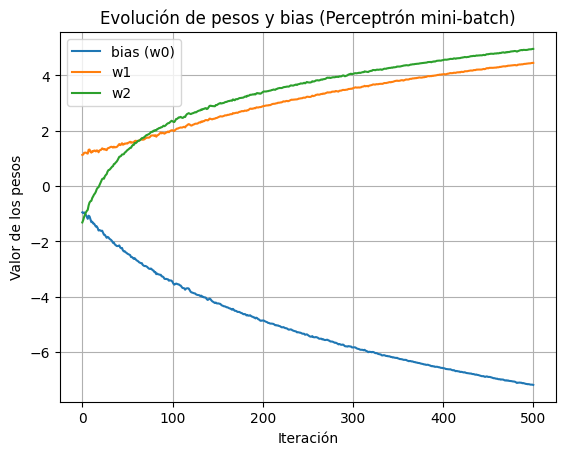

Taxa de erro: 0.0


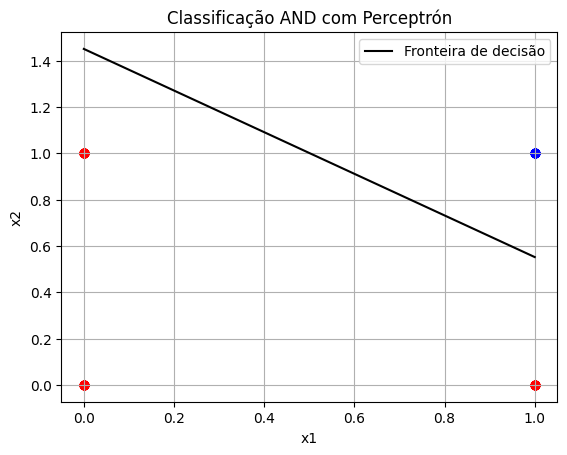

In [14]:
Nt = 100  # número de pontos de treinamento
x = np.round(np.random.uniform(0, 1, (Nt, 2)))

d = 1*(np.logical_and(x[:,0],x[:,1]))
d=d.reshape(Nt,1)
print(d.shape)

eta = 0.5  # passo de adaptação do algoritmo de Rosenblatt
Nb = 20
Ne = 100
dw = 2

#############  Complete o código a seguir
W = Rosenblatt_minibatch_EC(x, d, eta, Nt, Ne, Nb, dw)

# Wfinal deve ser os valores de pesos e bias da última iteração
Wfinal = W[-1,:]
print(Wfinal)
#############

# Gere um gráfico para mostrar os pesos e bias ao longo das iterações
import matplotlib.pyplot as plt

plt.figure()

# Iteraciones
iters = range(W.shape[0])

# Graficar bias y pesos
plt.plot(iters, W[:, 0], label="bias (w0)")
plt.plot(iters, W[:, 1], label="w1")
plt.plot(iters, W[:, 2], label="w2")

plt.xlabel("Iteración")
plt.ylabel("Valor de los pesos")
plt.title("Evolución de pesos y bias (Perceptrón mini-batch)")
plt.grid(True)
plt.legend()

plt.show()

import numpy as np
import matplotlib.pyplot as plt

#Generar datos de test
Nt_test = 100
x_test = np.round(np.random.uniform(0, 1, (Nt_test, 2)))

d_test = np.logical_and(x_test[:, 0], x_test[:, 1]).astype(int)

#Agregar bias
x_test_b = np.hstack((np.ones((Nt_test, 1)), x_test))

#Usar pesos finales
Wfinal = W[-1, :]

# Predicción
u = x_test_b @ Wfinal
y_pred = np.heaviside(u, 0)

#Error
error = np.mean(y_pred != d_test)
print("Taxa de erro:", error)

# Gráfico
plt.figure()

# Separar clases
for i in range(Nt_test):
    if y_pred[i] == 0:
        plt.scatter(x_test[i, 0], x_test[i, 1], color='red')
    else:
        plt.scatter(x_test[i, 0], x_test[i, 1], color='blue')

# Reta de separação
# Wfinal = [w0, w1, w2]
w0, w1, w2 = Wfinal

x_vals = np.linspace(0, 1, 100)

# Evitar división por cero
if w2 != 0:
    y_vals = -(w0 + w1 * x_vals) / w2
    plt.plot(x_vals, y_vals, 'k-', label="Fronteira de decisão")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Classificação AND com Perceptrón")
plt.legend()
plt.grid(True)

plt.show()